# Retail Sales Forecasting

This notebook presents a complete data science understanding. The project focuses on forecasting weekly sales for a retail chain using historical sales data, store characteristics, and external factors.

## 1. Problem Definition & Business Understanding

- **Objective:** Forecast weekly sales and understand key drivers (e.g., markdown promotions, holidays, economic factors) affecting sales performance.
- **Key Questions:**
  - What factors (store type, markdowns, holidays, economic indicators) drive sales?
  - How do promotional markdowns impact weekly sales?
  - Can we predict future sales accurately using historical data?
- **Success Metrics:** RMSE, MAE, R², and actionable insights for decision making.

### Import necessary Libraries

In [1043]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import LabelEncoder 
 
import scipy.stats as stats 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings 
warnings.filterwarnings('ignore') 

## 2. Data Integration

We have three datasets:

1. **features.csv**: Contains environmental and economic data (Temperature, Fuel_Price, CPI, Unemployment, MarkDowns, and IsHoliday).
2. **train.csv**: Contains weekly sales data (Store, Dept, Date, Weekly_Sales, IsHoliday).
3. **stores.csv**: Contains store characteristics (Store, Type, Size).

The datasets are merged using common keys (Store) to produce a final dataset for analysis. In this notebook, we assume the merged dataset is available as `df`.

In [1044]:
features = pd.read_csv("features.csv.xls")

In [1045]:
features.shape

(8190, 12)

**In Features has 8190 rows and 12 columns**

In [1046]:
stores = pd.read_csv("stores.csv.xls")

In [1047]:
stores.shape

(45, 3)

**In Store has 45 rows and 3 columns**

In [1048]:
train = pd.read_csv("train.csv.xls")

In [1049]:
train.shape

(421570, 5)

**In train has 421570 rows and 5 columns**

In [1050]:
# Merge train with features on 'Store'
df = pd.merge(train, features, how="inner")

In [1051]:
# Merge the result with stores on 'Store'
df = pd.merge(df, stores, on="Store", how="inner")

In [1052]:
df.shape

(421570, 16)

**df DataFrame has 421570 and 16 rows in initial phase**

In [1053]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [1054]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


**<pre>Bool Datatype: IsHoliday
Object Dataype: Type
Date type: Date 
Nulls: All MarkDown</pre>**

## 3. Data Cleaning & Preprocessing

- **Convert data types** (e.g., ensure the Date column is datetime).
- **Check for missing values** and handle them appropriately (e.g., fill missing markdowns with 0 if no discount was applied).

In [1055]:
# Convert the Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [1056]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [1057]:
df[['MarkDown1', 'MarkDown2','MarkDown3','MarkDown4','MarkDown5']].isnull().sum().mean()

np.float64(284486.2)

**Around 284486 Weeks are not any MarkDown scheme is apply**

In [1058]:
# fill the nulls whit 0
df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] = df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].fillna(0)

In [1059]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

## 4. Exploratory Data Analysis (EDA)
We perform univariate, bivariate, and multivariate analyses along with computing central tendency, dispersion, skewness, kurtosis, covariance, and correlation.

In [1060]:
num_columns_means = df.select_dtypes(include=np.number).mean()
num_columns_means

Store               22.200546
Dept                44.260317
Weekly_Sales     15981.258123
Temperature         60.090059
Fuel_Price           3.361027
MarkDown1         2590.074819
MarkDown2          879.974298
MarkDown3          468.087665
MarkDown4         1083.132268
MarkDown5         1662.772385
CPI                171.201947
Unemployment         7.960289
Size            136727.915739
dtype: float64

In [1061]:
num_columns_median = df.select_dtypes(include=np.number).median()
num_columns_median

Store               22.00000
Dept                37.00000
Weekly_Sales      7612.03000
Temperature         62.09000
Fuel_Price           3.45200
MarkDown1            0.00000
MarkDown2            0.00000
MarkDown3            0.00000
MarkDown4            0.00000
MarkDown5            0.00000
CPI                182.31878
Unemployment         7.86600
Size            140167.00000
dtype: float64

In [1062]:
mode_values = df.mode().iloc[0]
mode_values

Store                          13.0
Dept                              1
Date            2011-12-23 00:00:00
Weekly_Sales                   10.0
IsHoliday                     False
Temperature                   50.43
Fuel_Price                    3.638
MarkDown1                       0.0
MarkDown2                       0.0
MarkDown3                       0.0
MarkDown4                       0.0
MarkDown5                       0.0
CPI                      129.855533
Unemployment                  8.099
Type                              A
Size                        39690.0
Name: 0, dtype: object

In [1063]:
df.drop(['Date','Type'], axis=1).skew()

Store            0.077763
Dept             0.358223
Weekly_Sales     3.262008
IsHoliday        3.359867
Temperature     -0.321404
Fuel_Price      -0.104901
MarkDown1        4.731304
MarkDown2       10.645956
MarkDown3       14.922341
MarkDown4        8.077666
MarkDown5        9.964519
CPI              0.085219
Unemployment     1.183743
Size            -0.325850
dtype: float64

In [1064]:
df.drop(['Date','Type'], axis=1).kurt()

Store            -1.146503
Dept             -1.215571
Weekly_Sales     21.491290
IsHoliday         9.288747
Temperature      -0.635922
Fuel_Price       -1.185405
MarkDown1        34.917236
MarkDown2       145.421293
MarkDown3       248.095371
MarkDown4        86.242339
MarkDown5       183.408065
CPI              -1.829714
Unemployment      2.731217
Size             -1.206346
dtype: float64

In [1065]:
df.drop(['Date','Type'], axis=1).corr()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
Store,1.000000,0.024004,-0.085195,-0.000548,-0.050097,0.065290,-0.059844,-0.033829,-0.020331,-0.042724,-0.012452,-0.211088,0.208552,-0.182881
Dept,0.024004,1.000000,0.148032,0.000916,0.004437,0.003572,0.001494,0.000587,0.001475,0.001937,0.002668,-0.007477,0.007837,-0.002966
Weekly_Sales,-0.085195,0.148032,1.000000,0.012774,-0.002312,-0.000120,0.047172,0.020716,0.038562,0.037467,0.050465,-0.020921,-0.025864,0.243828
IsHoliday,-0.000548,0.000916,0.012774,1.000000,-0.155949,-0.078281,-0.003521,0.207604,0.266471,0.011565,-0.015235,-0.001944,0.010460,0.000593
Temperature,-0.050097,0.004437,-0.002312,-0.155949,1.000000,0.143859,-0.026415,-0.179672,-0.056026,-0.050281,-0.014752,0.182112,0.096730,-0.058313
Fuel_Price,0.065290,0.003572,-0.000120,-0.078281,0.143859,1.000000,0.297056,0.029153,0.018615,0.166622,0.215420,-0.164210,-0.033853,0.003361
MarkDown1,-0.059844,0.001494,0.047172,-0.003521,-0.026415,0.297056,1.000000,0.174868,-0.014411,0.838904,0.415050,0.010915,-0.105168,0.169788
MarkDown2,-0.033829,0.000587,0.020716,0.207604,-0.179672,0.029153,0.174868,1.000000,-0.006080,0.113250,0.131735,-0.003554,-0.041427,0.078372
MarkDown3,-0.020331,0.001475,0.038562,0.266471,-0.056026,0.018615,-0.014411,-0.006080,1.000000,-0.012020,0.042471,-0.005839,-0.018078,0.033641
MarkDown4,-0.042724,0.001937,0.037467,0.011565,-0.050281,0.166622,0.838904,0.113250,-0.012020,1.000000,0.303370,-0.002047,-0.076513,0.127334


In [1066]:
numerical_columns = df.select_dtypes(include=np.number).columns

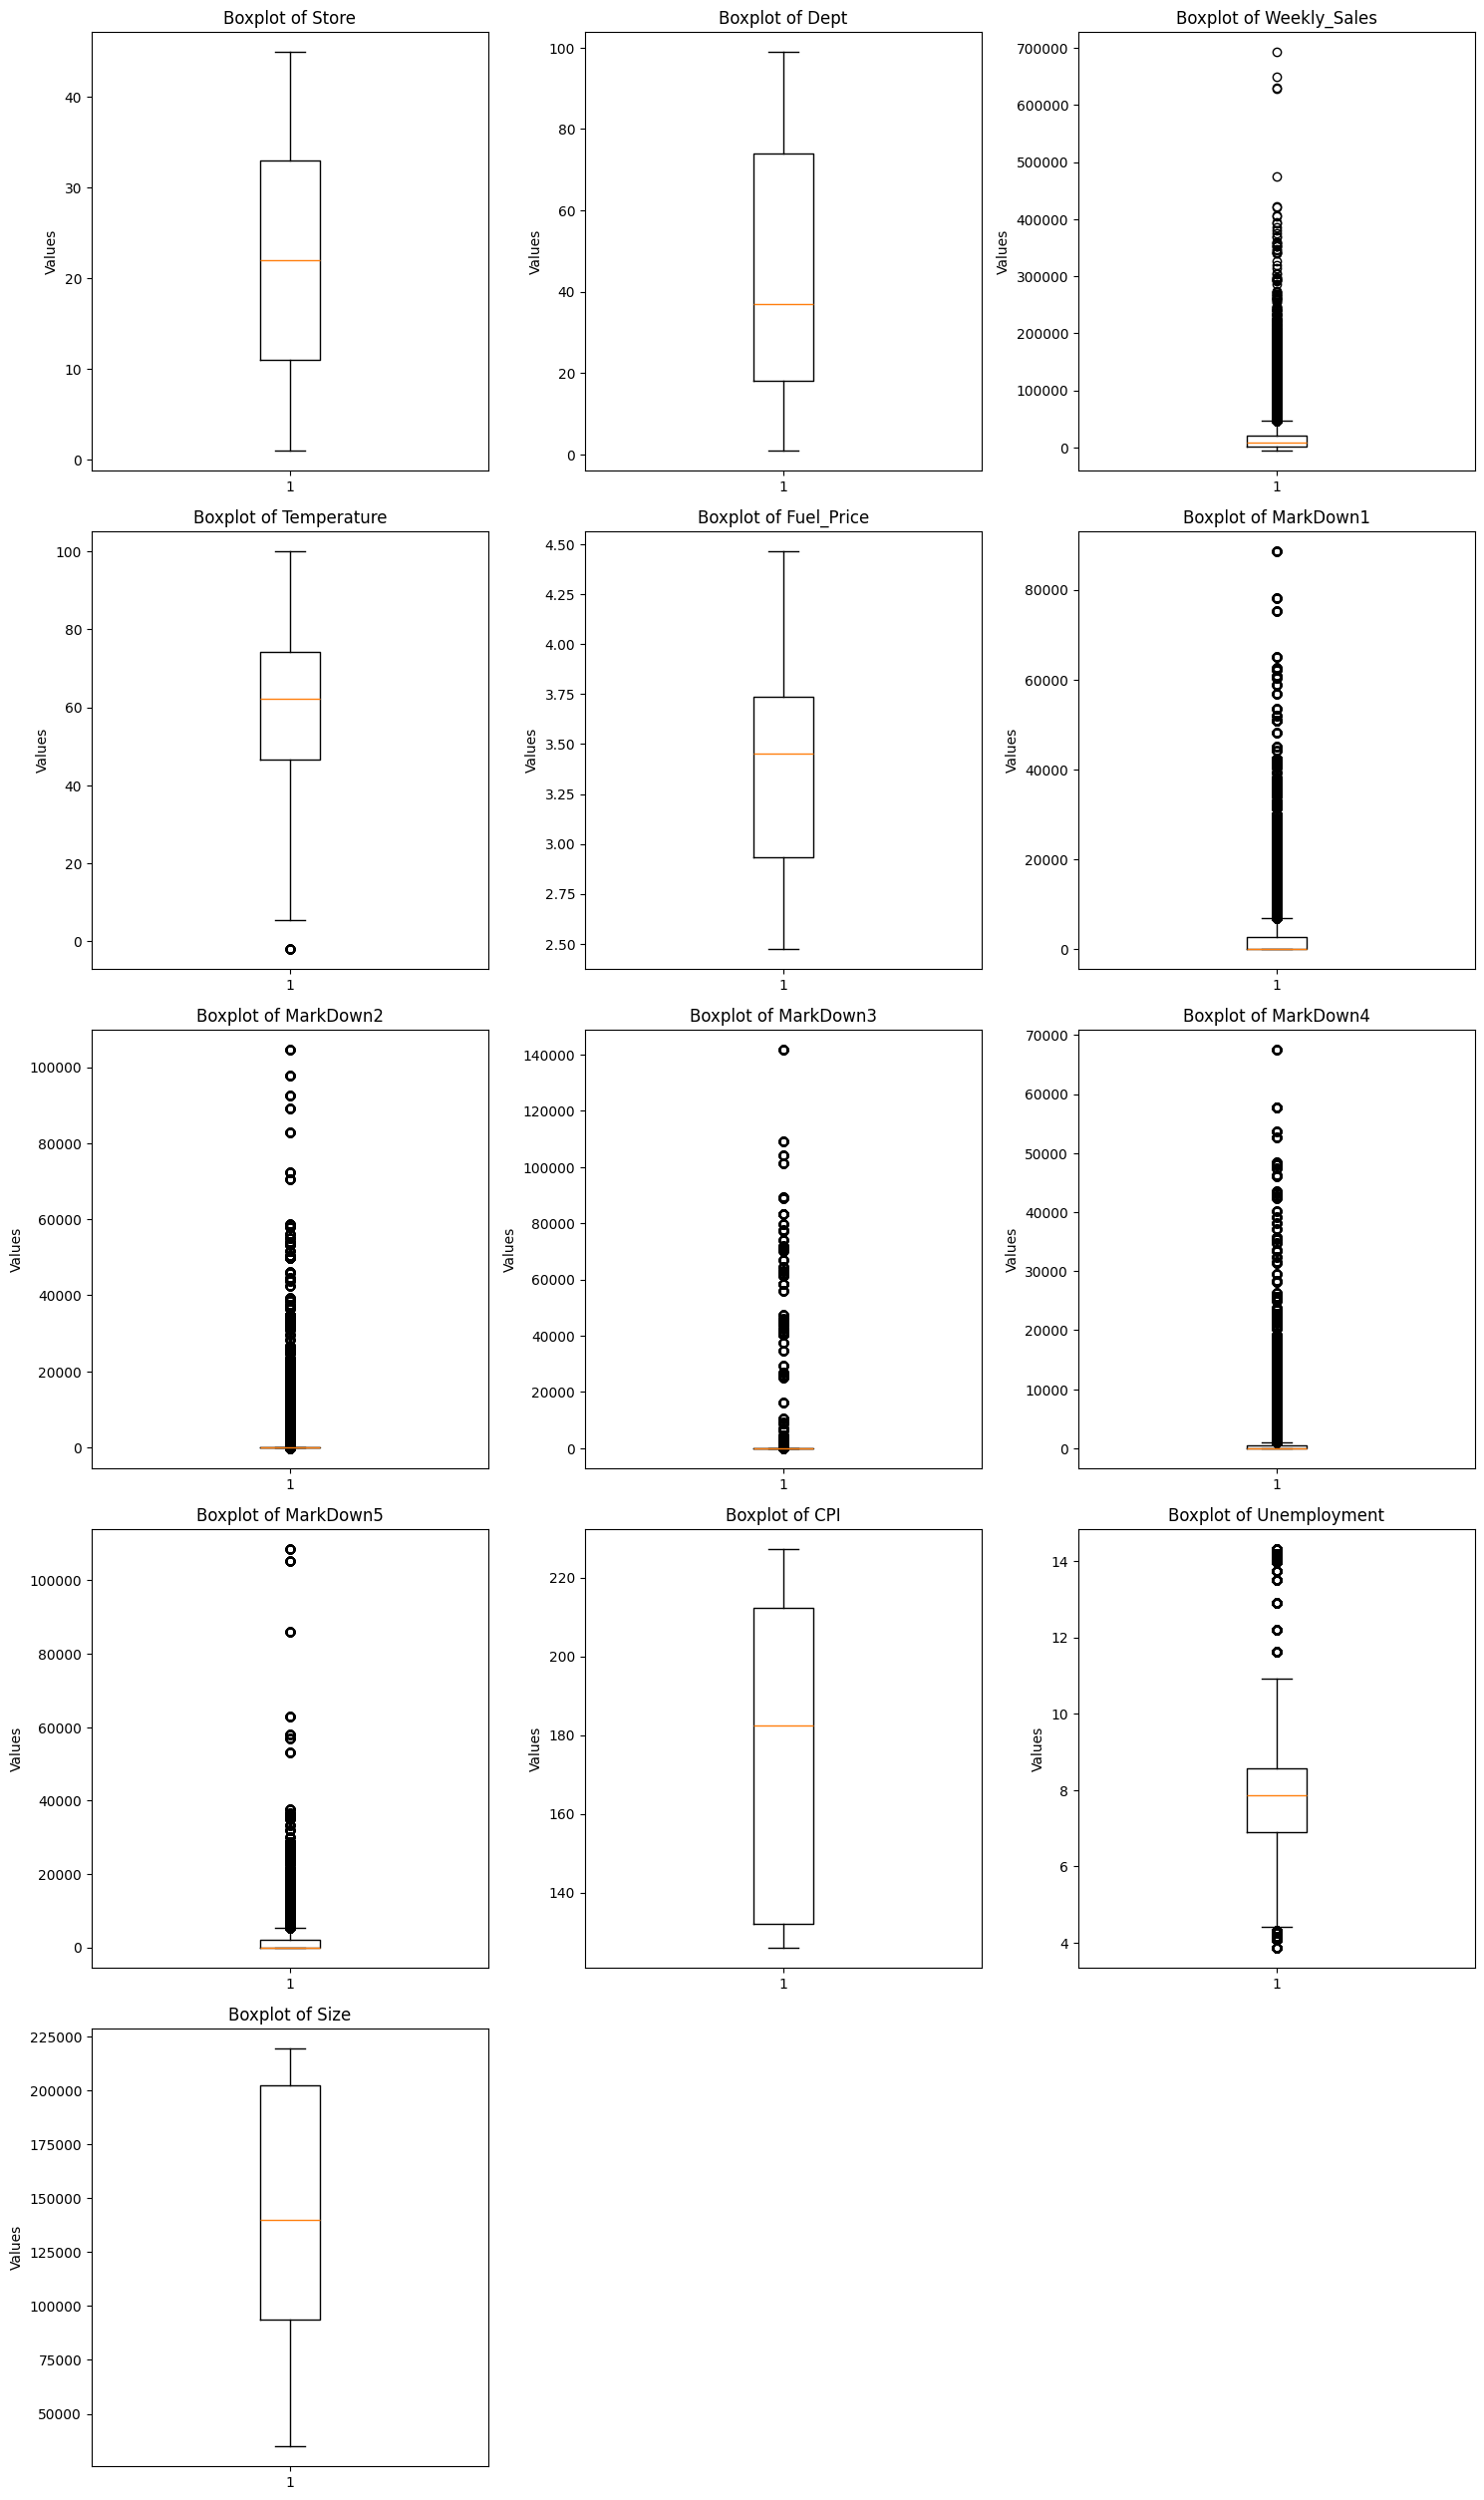

In [1067]:
num_cols = len(numerical_columns)
plt.figure(figsize=(15, 5 * num_cols))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(num_cols, 3, i)
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')

plt.tight_layout()
plt.show()

In [1068]:
num_data = df.select_dtypes(include = np.number)
Q1 = num_data.quantile(0.25)
Q3 = num_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

In [1069]:
df = df[(df['Store'] > lower_bound['Store']) & (df['Store'] < upper_bound['Store'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['Dept'] > lower_bound['Dept']) & (df['Dept'] < upper_bound['Dept'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['Weekly_Sales'] > lower_bound['Weekly_Sales']) & (df['Weekly_Sales'] < upper_bound['Weekly_Sales'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['Temperature'] > lower_bound['Temperature']) & (df['Temperature'] < upper_bound['Temperature'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['Fuel_Price'] > lower_bound['Fuel_Price']) & (df['Fuel_Price'] < upper_bound['Fuel_Price'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['MarkDown1'] > lower_bound['MarkDown1']) & (df['MarkDown1'] < upper_bound['MarkDown1'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['MarkDown2'] > lower_bound['MarkDown2']) & (df['MarkDown2'] < upper_bound['MarkDown2'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['MarkDown3'] > lower_bound['MarkDown3']) & (df['MarkDown3'] < upper_bound['MarkDown3'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['MarkDown4'] > lower_bound['MarkDown4']) & (df['MarkDown4'] < upper_bound['MarkDown4'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['MarkDown5'] > lower_bound['MarkDown5']) & (df['MarkDown5'] < upper_bound['MarkDown5'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['CPI'] > lower_bound['CPI']) & (df['CPI'] < upper_bound['CPI'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['Unemployment'] > lower_bound['Unemployment']) & (df['Unemployment'] < upper_bound['Unemployment'])]
df.reset_index(drop=True, inplace=True)
df = df[(df['Size'] > lower_bound['Size']) & (df['Size'] < upper_bound['Size'])]
df.reset_index(drop=True, inplace=True)

In [1070]:
df['Weekly_Sales']


0         24924.50
1         46039.49
2         41595.55
3         19403.54
4         21827.90
            ...   
247194     1058.84
247195     1167.90
247196      749.18
247197     1061.02
247198      760.01
Name: Weekly_Sales, Length: 247199, dtype: float64

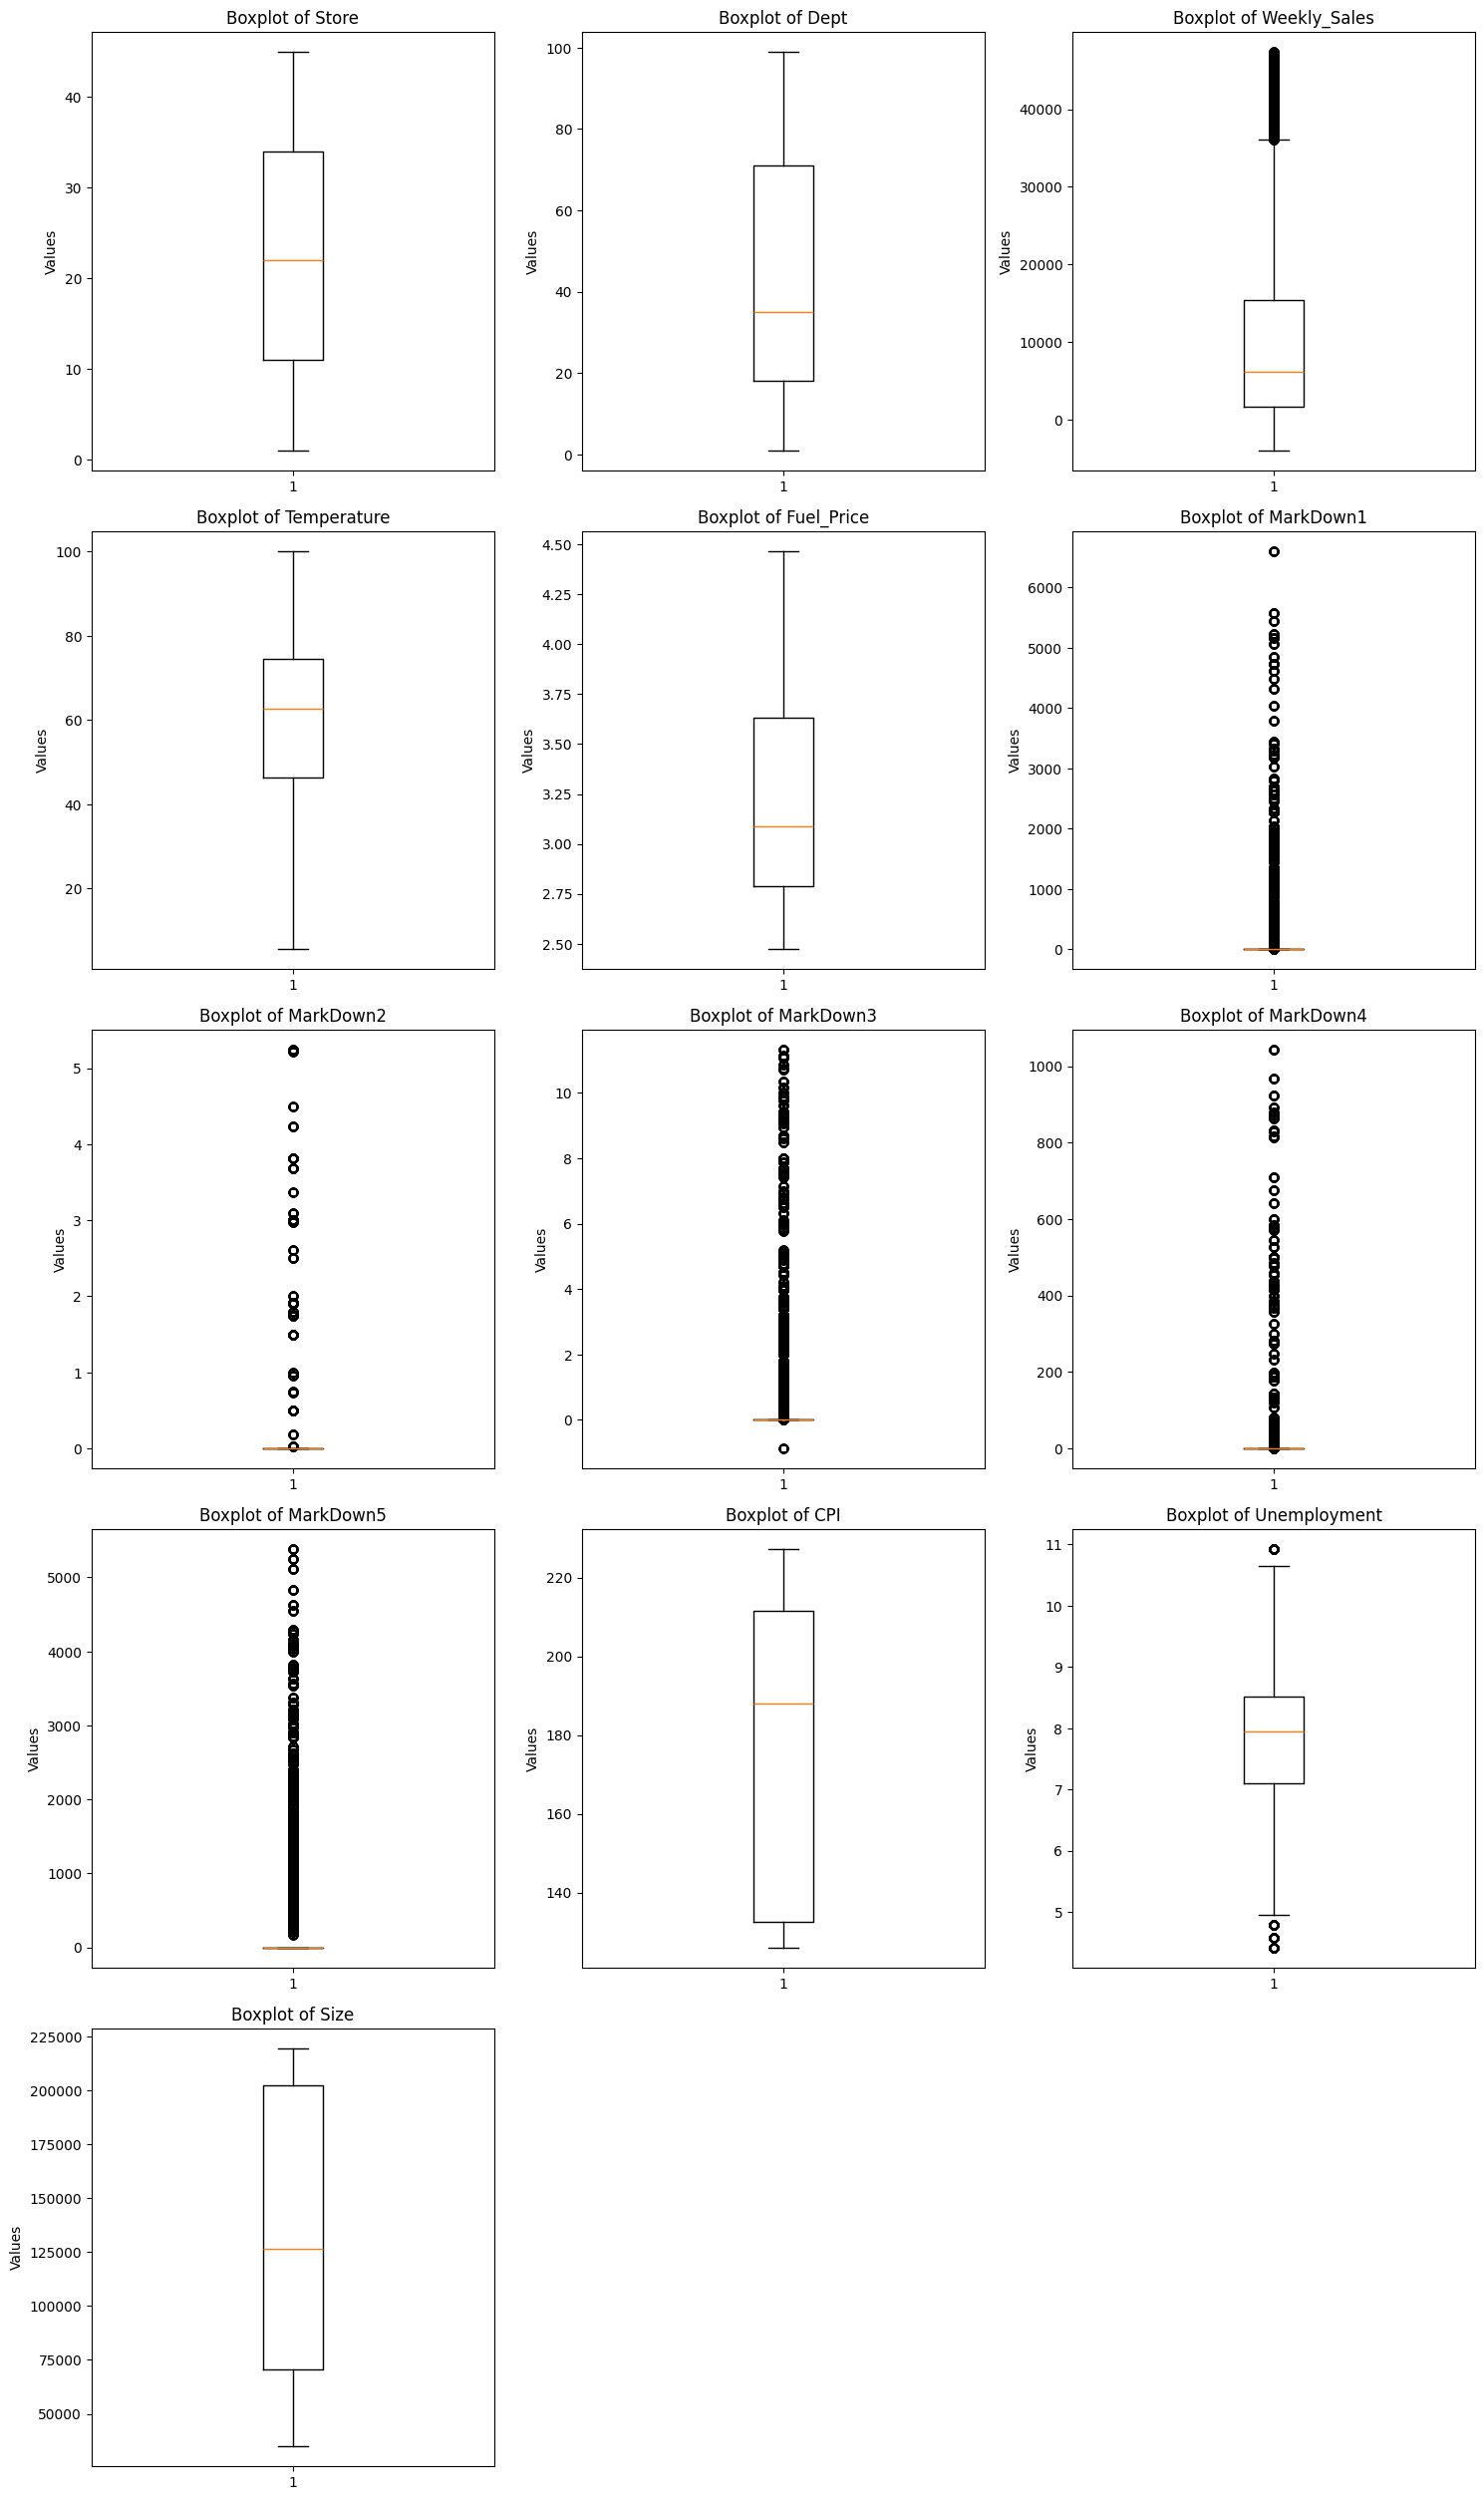

In [1071]:
num_cols = len(numerical_columns)
plt.figure(figsize=(15, 5 * num_cols))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(num_cols, 3, i)
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')

plt.tight_layout()
plt.show()

In [1072]:
# plt.figure(figsize=[20,10])
# sns.heatmap(df.drop(['Date','Type'], axis=1).corr(), annot = True)

In [1073]:
# # Plot histogram & KDE for Weekly Sales
# plt.figure(figsize=(10, 5))
# sns.histplot(df['Weekly_Sales'], kde=True, color='blue')
# plt.title('Distribution of Weekly Sales')
# plt.xlabel('Weekly Sales')
# plt.ylabel('Frequency')
# plt.show()


In [1074]:
# plt.figure(figsize=(12, 5))
# sns.histplot(df['CPI'], bins=50, kde=True)
# plt.title('Distribution of CPI')
# plt.xlabel('CPI')
# plt.ylabel('Frequency')
# plt.show()

In [1075]:
# plt.figure(figsize=(12, 5))
# sns.histplot(df['Unemployment'], bins=50, kde=True)
# plt.title('Distribution of Unemployment')
# plt.xlabel('Unemployment Rate')
# plt.ylabel('Frequency')
# plt.show()

In [1076]:
# # Bivariate Analysis
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'])
# plt.title('Weekly Sales vs Temperature')
# plt.xlabel('Temperature')
# plt.ylabel('Weekly Sales')
# plt.show()

In [1077]:
# plt.figure(figsize=(6, 4))
# sns.barplot(x="IsHoliday", y="Weekly_Sales", data=df)
# plt.title("Holiday vs. Non-Holiday Sales")
# plt.show()

In [1078]:
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=df['Fuel_Price'], y=df['CPI'])
# plt.title('CPI vs Fuel Price')
# plt.xlabel('Fuel Price')
# plt.ylabel('CPI')
# plt.show()

In [1079]:
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=df['Size'], y=df['Weekly_Sales'])
# plt.title('Store Size vs Weekly Sales')
# plt.xlabel('Store Size')
# plt.ylabel('Weekly Sales')
# plt.show()

In [1080]:
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='Type', y='Weekly_Sales', data=df)
# plt.title('Weekly Sales by Store Type')
# plt.show()

In [1081]:
#Multivariate

In [1082]:
# plt.figure(figsize=(12, 6))
# sns.heatmap(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr(), annot=True)
# plt.title('Correlation Heatmap')
# plt.show()

In [1083]:
# sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
# plt.show()

<Axes: >

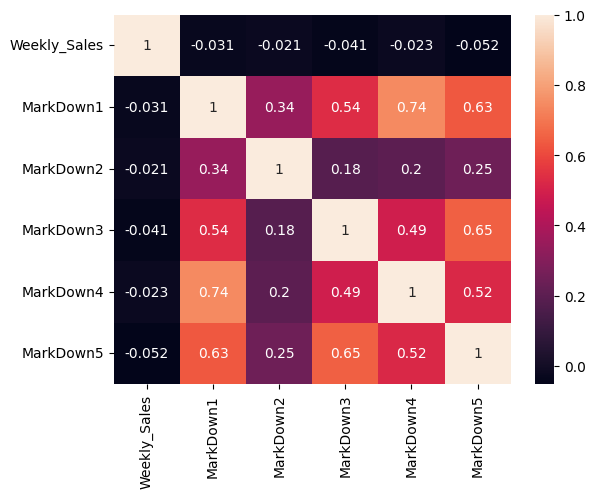

In [1084]:
sns.heatmap(df[['Weekly_Sales', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].corr(), annot = True)

In [1085]:
# sns.lineplot(x=df["MarkDown1"], y=df["MarkDown5"])

In [1086]:
# plt.plot(df["MarkDown5"], label='Line 1')
# plt.plot(df["MarkDown1"], label='Line 2')
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.legend()
# plt.show()

In [1087]:
# sns.lineplot(x=df["MarkDown1"],y=df["Weekly_Sales"], label='Line 1')
# sns.lineplot(x=df["MarkDown5"],y=df["Weekly_Sales"], label='Line 2')
# plt.show()

In [1088]:
# sns.scatterplot(x=df["MarkDown1"], y=df["Weekly_Sales"])
# plt.title("Weekly Sales vs. MarkDown1")
# plt.show()

In [1089]:
# df.groupby('Type')[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].mean()

## 5. Encoding, Scaling and VIF

- **Label Encoding:** Used for `IsHoliday` and `Type` since they are categorical.
- **Standard Scaling:** Applied `StandardScaler` to normalize numerical features (`Weekly Sales`, `Temperature`, `Fuel Price`, etc.) to improve ML model performance.
- 
**VIF Calculation:**- Measures multicollinearity among numerical variables.
- High VIF values (>10) indicate strong multicollinearity, requiring feature selection.

In [1090]:
# Encoding categorical variables
label_encoder = LabelEncoder()
df['IsHoliday'] = label_encoder.fit_transform(df['IsHoliday'])
df['Type'] = label_encoder.fit_transform(df['Type'])

In [1091]:
# Scaling numerical features
scaler = StandardScaler()
numeric_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size']
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [1092]:
# Compute VIF (Variance Inflation Factor) to detect multicollinearity
vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_columns
vif_data['VIF'] = [variance_inflation_factor(df[numeric_columns].values, i) for i in range(len(numeric_columns))]
print(vif_data)

         Feature       VIF
0   Weekly_Sales  1.057178
1    Temperature  1.127648
2     Fuel_Price  1.155808
3      MarkDown1  2.951078
4      MarkDown2  1.151725
5      MarkDown3  1.842741
6      MarkDown4  2.314866
7      MarkDown5  2.244957
8            CPI  1.153411
9   Unemployment  1.069009
10          Size  1.112592


## 6. Model Building & Machine Learning

In this section, we build a baseline machine learning model to forecast weekly sales. We will:

- Define the target (`Weekly_Sales`) and features
- Split the data into training and testing sets
- Train a model using Linear Regression
- Evaluate the model performance using RMSE, MAE, and R²

In [1093]:
# Define target and features
target = df['Weekly_Sales']
features = df.drop(columns=['Weekly_Sales', 'Date'])

In [1094]:
# Split the data (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [1095]:
# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [1096]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test)

In [1098]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
r2

0.05573388980310012